11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 [D loss: 0.6879] [G loss: 1.1526]
Epoch 100 [D loss: 2.6692] [G loss: 0.0610]
Epoch 200 [D loss: 3.0780] [G loss: 0.0318]
Epoch 300 [D loss: 3.3115] [G loss: 0.0217]
Epoch 400 [D loss: 3.4814] [G loss: 0.0165]
Epoch 500 [D loss: 3.6141] [G loss: 0.0133]
Epoch 600 [D loss: 3.7239] [G loss: 0.0112]
Epoch 700 [D loss: 3.8161] [G loss: 0.0096]
Epoch 800 [D loss: 3.8965] [G loss: 0.0085]
Epoch 900 [D loss: 3.9683] [G loss: 0.0076]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


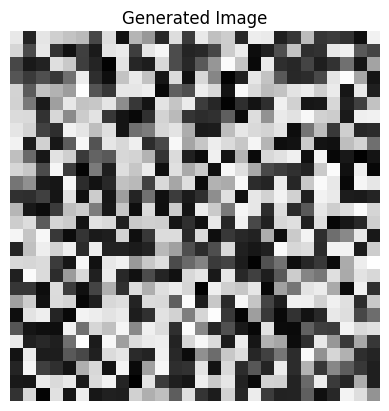

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Preprocess Dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0  # Normalize to [0, 1]
x_train = x_train.reshape(-1, 784) # Flatten 28x28 images to 784 vectors

# 2. Build Generator Model
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=100),
    tf.keras.layers.Dense(784, activation='sigmoid')
])

# 3. Build Discriminator Model
discriminator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=784),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Build Combined GAN Model
# When training the combined model, we only want to update the generator
discriminator.trainable = False
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Training Loop
epochs = 1000  # Increased for better results
batch_size = 32

for epoch in range(epochs):
    # --- Train Discriminator ---
    # Select a random batch of real images
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    # Generate a batch of fake images
    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_images = generator.predict(noise, verbose=0)

    # Train on real (labels = 1) and fake (labels = 0)
    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # --- Train Generator ---
    noise = np.random.normal(0, 1, (batch_size, 100))
    # We want the discriminator to think these are real (label = 1)
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # Progress monitoring
    if epoch % 100 == 0:
        print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}] [G loss: {g_loss:.4f}]")

# 6. Generate and Display Output
noise = np.random.normal(0, 1, (1, 100))
generated_image = generator.predict(noise)
plt.imshow(generated_image.reshape(28, 28), cmap='gray')
plt.title("Generated Image")
plt.axis('off')
plt.show()